# Process internally-triggered spiracle videos

**English.** This notebook processes internally-triggered high-speed videos of insect spiracles. The input is a 5-column XLSX containing, per frame, two ROI intensity traces (one for the spiracle 1 ROI, and another reference ROI; used to detect when the spiracle is occluded) and a raw spiracle-aperture measurement. The pipeline:

1. **Read & validate** the XLSX, confirming the two ROI columns are frame-aligned.
2. **Filter occluded frames** with a centered rolling-median deviation test on the two ROI intensities.
3. **Rescale** the raw aperture to a 0–1 range using percentile anchors.
4. **Write** a cleaned 6-column CSV (`*_after_correction.csv`) and **plot** the rescaled aperture over time, exporting publication-ready SVG + PNG.

Two cells: **Cell 1** does the cleaning/rescaling and writes the CSV; **Cell 2** reads that CSV and produces the aperture-vs-time figure. Key parameters (input path, `FPS`, rolling window, deviation threshold) are set as constants at the top of Cell 1.

**中文。** 本 notebook 处理昆虫气门的内部触发高速视频。输入是 5 列 XLSX，每帧包含两条 ROI 强度曲线（用于检测气门何时被遮挡）以及一个原始气门孔径测量值。处理流程：

1. **读取与校验** XLSX，确认两个 ROI 列帧对齐。
2. **过滤遮挡帧**：对两条 ROI 强度做居中滚动中位数偏差检验。
3. **重标度**：用百分位锚点将原始孔径映射到 0–1 区间。
4. **写出** 清洗后的 6 列 CSV（`*_after_correction.csv`）并**绘制** 孔径随时间的曲线，导出可用于发表的 SVG + PNG。

共两格：**第 1 格** 完成清洗/重标度并写出 CSV；**第 2 格** 读取该 CSV 并生成孔径–时间图。关键参数（输入路径、`FPS`、滚动窗口、偏差阈值）以常量形式置于第 1 格顶部。

## Cell 1 — Internal-triggered XLSX cleaner

**English.** Main pipeline. Reads the 5-column raw Excel (`frame_a, intensity_a, frame_b, intensity_b, aperture_raw`), validates that the two ROIs are frame-aligned, then applies a centered rolling-median occlusion filter: a frame is dropped if **either** ROI's relative deviation `|raw − median| / median` exceeds `REL_THRESH` (medians below `MIN_MEDIAN` are skipped to avoid divide-by-≈0). A log-y diagnostic histogram of the deviations (with threshold / p95 / p99.9 markers) helps tune `REL_THRESH`. Surviving frames have `aperture_raw` rescaled to 0–1 via the 1st→0 / 99th→1 percentiles, and the result is written as a 6-column CSV `<input>_after_correction.csv` (`frame_number, time_s, intensity_1, intensity_2, aperture_raw, aperture_rescaled`; `time_s = frame / FPS`, `FPS = 1000`). `set_plot_style()` configures editable-text SVG/PDF export.

**中文。** 主处理流程。读取 5 列原始 Excel（`frame_a, intensity_a, frame_b, intensity_b, aperture_raw`），校验两个 ROI 帧对齐，然后用居中滚动中位数做遮挡过滤：只要**任一** ROI 的相对偏差 `|原始值 − 中位数| / 中位数` 超过 `REL_THRESH` 即丢弃该帧（中位数低于 `MIN_MEDIAN` 时跳过，避免除以接近 0）。对数纵轴的偏差诊断直方图（含阈值 / p95 / p99.9 标记）帮助调整 `REL_THRESH`。存活帧的 `aperture_raw` 以第 1 百分位→0、第 99 百分位→1 重标度到 0–1，结果写为 6 列 CSV `<输入名>_after_correction.csv`（`frame_number, time_s, intensity_1, intensity_2, aperture_raw, aperture_rescaled`；`time_s = 帧号 / FPS`，`FPS = 1000`）。`set_plot_style()` 配置可编辑文字的 SVG/PDF 导出。

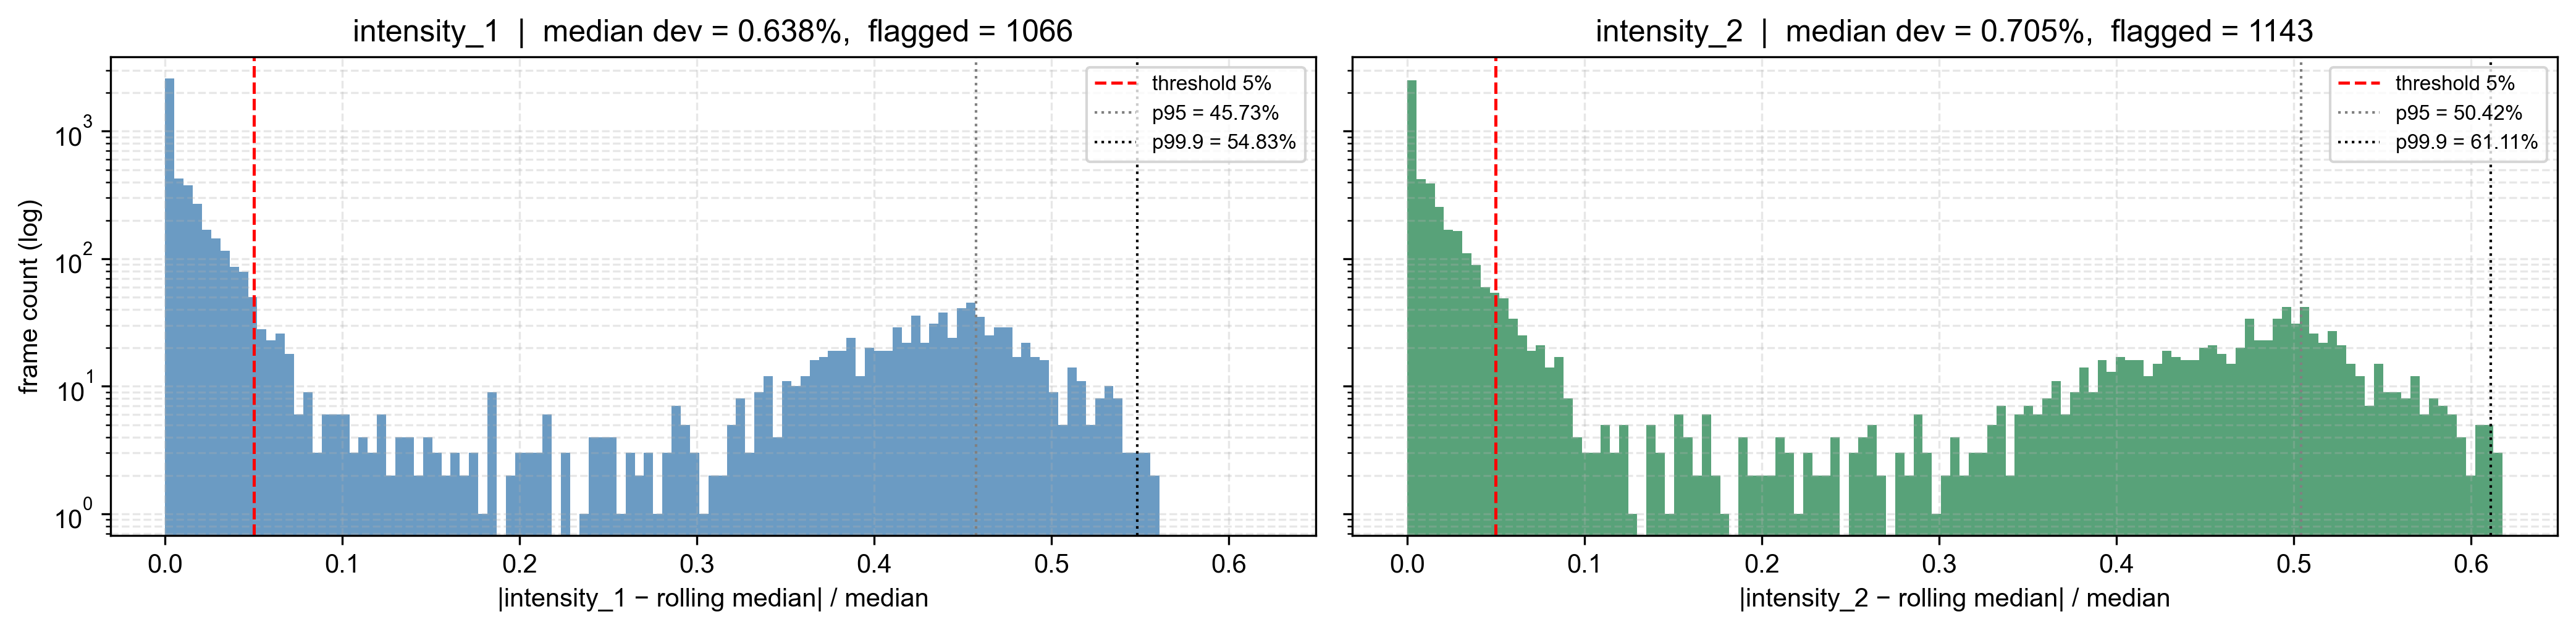

Kept 4197 / Dropped 1148 of 5345 frames
Rescaling reference points (percentile-based):
  1st  percentile (→ 0) : 0.9872
  99th percentile (→ 1) : 1.1210
Rescaled range          : -0.0389 – 1.1479
Saved: K:\Yichen\spiracle_movies\internal_trigger_flight_onset_offset_aligned_after_correction.csv
 frame_number  time_s  intensity_1  intensity_2  aperture_raw  aperture_rescaled
            0   0.000     1404.852     1396.841      1.005735           0.138228
            1   0.001     1403.210     1395.367      1.005621           0.137373
            2   0.002     1404.644     1397.097      1.005402           0.135737
            3   0.003     1402.654     1395.796      1.004913           0.132084
            4   0.004     1403.870     1396.484      1.005289           0.134893
            5   0.005     1403.437     1396.489      1.004975           0.132547
            6   0.006     1404.000     1394.723      1.006651           0.145080
            7   0.007     1404.482     1395.392      1.00

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Internal-triggered XLSX cleaner
# 读取 5 列 XLSX → 滚动中位数偏差过滤遮挡帧 → 气门孔径 0–1 重标度 → 写
# *_after_correction.csv（6 列：frame_number, time_s, intensity_1, intensity_2,
# aperture_raw, aperture_rescaled）
#
# 输入列约定：
#   col 0: frame_a   col 1: intensity_a   col 2: frame_b
#   col 3: intensity_b   col 4: aperture_raw
# ═══════════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def set_plot_style():
    """
    Opt-in matplotlib defaults for editable-text SVGs (Affinity/Illustrator safe).
    Call once near the top of a notebook. Idempotent.
    """
    import matplotlib as mpl
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial']
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    mpl.rcParams['figure.dpi'] = 300
    mpl.rcParams['savefig.dpi'] = 300

set_plot_style()

XLSX_FILE = r"K:\Yichen\spiracle_movies\internal_trigger_flight_onset_offset_aligned.xlsx"
SHEET     = 0          # sheet name or 0-based index
HAS_HEADER = True      # set False if the first row is data (no column names)

FPS          = 1000.0  # internal-triggered acquisition rate
ROLL_WIN     = 51      # centered rolling window (frames) — matches Block 2.5
REL_THRESH   = 0.05    # |raw − median| / median > 10%  → flag
MIN_MEDIAN   = 50.0    # skip flag if rolling median below this (avoid div ≈ 0)

raw = pd.read_excel(XLSX_FILE, sheet_name=SHEET,
                    header=0 if HAS_HEADER else None)
if raw.shape[1] < 5:
    raise ValueError(f"Expected ≥5 columns, got {raw.shape[1]} from {XLSX_FILE!r}.")

df = raw.iloc[:, :5].copy()
df.columns = ["frame_a", "intensity_a", "frame_b", "intensity_b", "aperture_raw"]
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["frame_a", "frame_b"]).reset_index(drop=True)

if not (df["frame_a"].astype(int).values == df["frame_b"].astype(int).values).all():
    raise ValueError("frame_a (col 1) and frame_b (col 3) differ — input is unaligned.")

# Block 2.5–style occlusion filter on the two ROI intensities
med_a = df["intensity_a"].rolling(ROLL_WIN, center=True, min_periods=1).median()
med_b = df["intensity_b"].rolling(ROLL_WIN, center=True, min_periods=1).median()

with np.errstate(divide="ignore", invalid="ignore"):
    dev_a = np.where(med_a >= MIN_MEDIAN,
                     np.abs(df["intensity_a"].values - med_a.values) / med_a.values, 0.0)
    dev_b = np.where(med_b >= MIN_MEDIAN,
                     np.abs(df["intensity_b"].values - med_b.values) / med_b.values, 0.0)

flag_a = dev_a > REL_THRESH
flag_b = dev_b > REL_THRESH
flagged = flag_a | flag_b

# ── Diagnostic: log-y histogram of |raw − rolling_median| / median ──
# 用来挑选合适的 REL_THRESH（红色虚线 = 当前阈值）
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
bins = np.linspace(0.0, max(float(np.nanmax(dev_a)),
                            float(np.nanmax(dev_b)),
                            REL_THRESH * 1.5), 120)
for ax, dev, raw_name, flag, color in (
    (axes[0], dev_a, "intensity_1", flag_a, "steelblue"),
    (axes[1], dev_b, "intensity_2", flag_b, "seagreen"),
):
    ax.hist(dev, bins=bins, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(REL_THRESH, color="red", linestyle="--", linewidth=1.2,
               label=f"threshold {REL_THRESH*100:.0f}%")
    q50  = float(np.nanquantile(dev, 0.50))
    q95  = float(np.nanquantile(dev, 0.95))
    q999 = float(np.nanquantile(dev, 0.999))
    ax.axvline(q95,  color="gray",  linestyle=":", linewidth=1,
               label=f"p95 = {q95*100:.2f}%")
    ax.axvline(q999, color="black", linestyle=":", linewidth=1,
               label=f"p99.9 = {q999*100:.2f}%")
    ax.set_yscale("log")
    ax.set_xlabel(f"|{raw_name} − rolling median| / median")
    ax.set_title(f"{raw_name}  |  median dev = {q50*100:.3f}%,  flagged = {int(flag.sum())}")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
axes[0].set_ylabel("frame count (log)")
plt.tight_layout()
plt.show()
plt.close(fig)

kept = df.loc[~flagged].reset_index(drop=True)
print(f"Kept {len(kept)} / Dropped {int(flagged.sum())} of {len(df)} frames")

# Rescale aperture to 0–1 using 1st / 99th percentiles (matches Step1 Block 3)
# p1 → 0, p99 → 1; values outside fall below 0 / above 1.
ap = kept["aperture_raw"].astype(float).values
N = len(ap)
if N == 0:
    raise RuntimeError("No frames survived the filter — loosen REL_THRESH or check input.")
lo = float(np.nanpercentile(ap, 1.0))
hi = float(np.nanpercentile(ap, 99.0))
if hi == lo:
    raise RuntimeError("aperture_raw has no dynamic range (p1 == p99).")
aperture_rescaled = (ap - lo) / (hi - lo)
print(f"Rescaling reference points (percentile-based):")
print(f"  1st  percentile (→ 0) : {lo:.4f}")
print(f"  99th percentile (→ 1) : {hi:.4f}")
print(f"Rescaled range          : {aperture_rescaled.min():.4f} – {aperture_rescaled.max():.4f}")

frame_number = kept["frame_a"].astype(int).values
out = pd.DataFrame({
    "frame_number":      frame_number,
    "time_s":            frame_number / FPS,
    "intensity_1":       kept["intensity_a"].values,
    "intensity_2":       kept["intensity_b"].values,
    "aperture_raw":      ap,
    "aperture_rescaled": aperture_rescaled,
})

out_csv = os.path.splitext(XLSX_FILE)[0] + "_after_correction.csv"
out.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print(out.head(8).to_string(index=False))


## Cell 2 — Plot rescaled aperture vs. time

**English.** Visualizes the cleaned result from Cell 1. Reads `<stem>_after_correction.csv` and plots `aperture_rescaled` against `time_s` as a thin steel-blue line (y-axis fixed to 0–1, dashed grid, title showing the file name). Saves the figure as both SVG (vector, editable text) and PNG (150 DPI raster) next to the input, displays it, and prints the saved paths. The figure size (14×4) and styling match the Step 1 `_save_combined_svg` convention.

**中文。** 可视化第一格清洗后的结果。读取 `<主干>_after_correction.csv`，以细的钢蓝色线绘制 `aperture_rescaled` 对 `time_s` 的曲线（纵轴固定为 0–1、虚线网格、标题显示文件名）。将图同时保存为 SVG（矢量、可编辑文字）和 PNG（150 DPI 位图）于输入文件同目录，显示图像并打印保存路径。图尺寸（14×4）与风格沿用 Step 1 的 `_save_combined_svg` 约定。

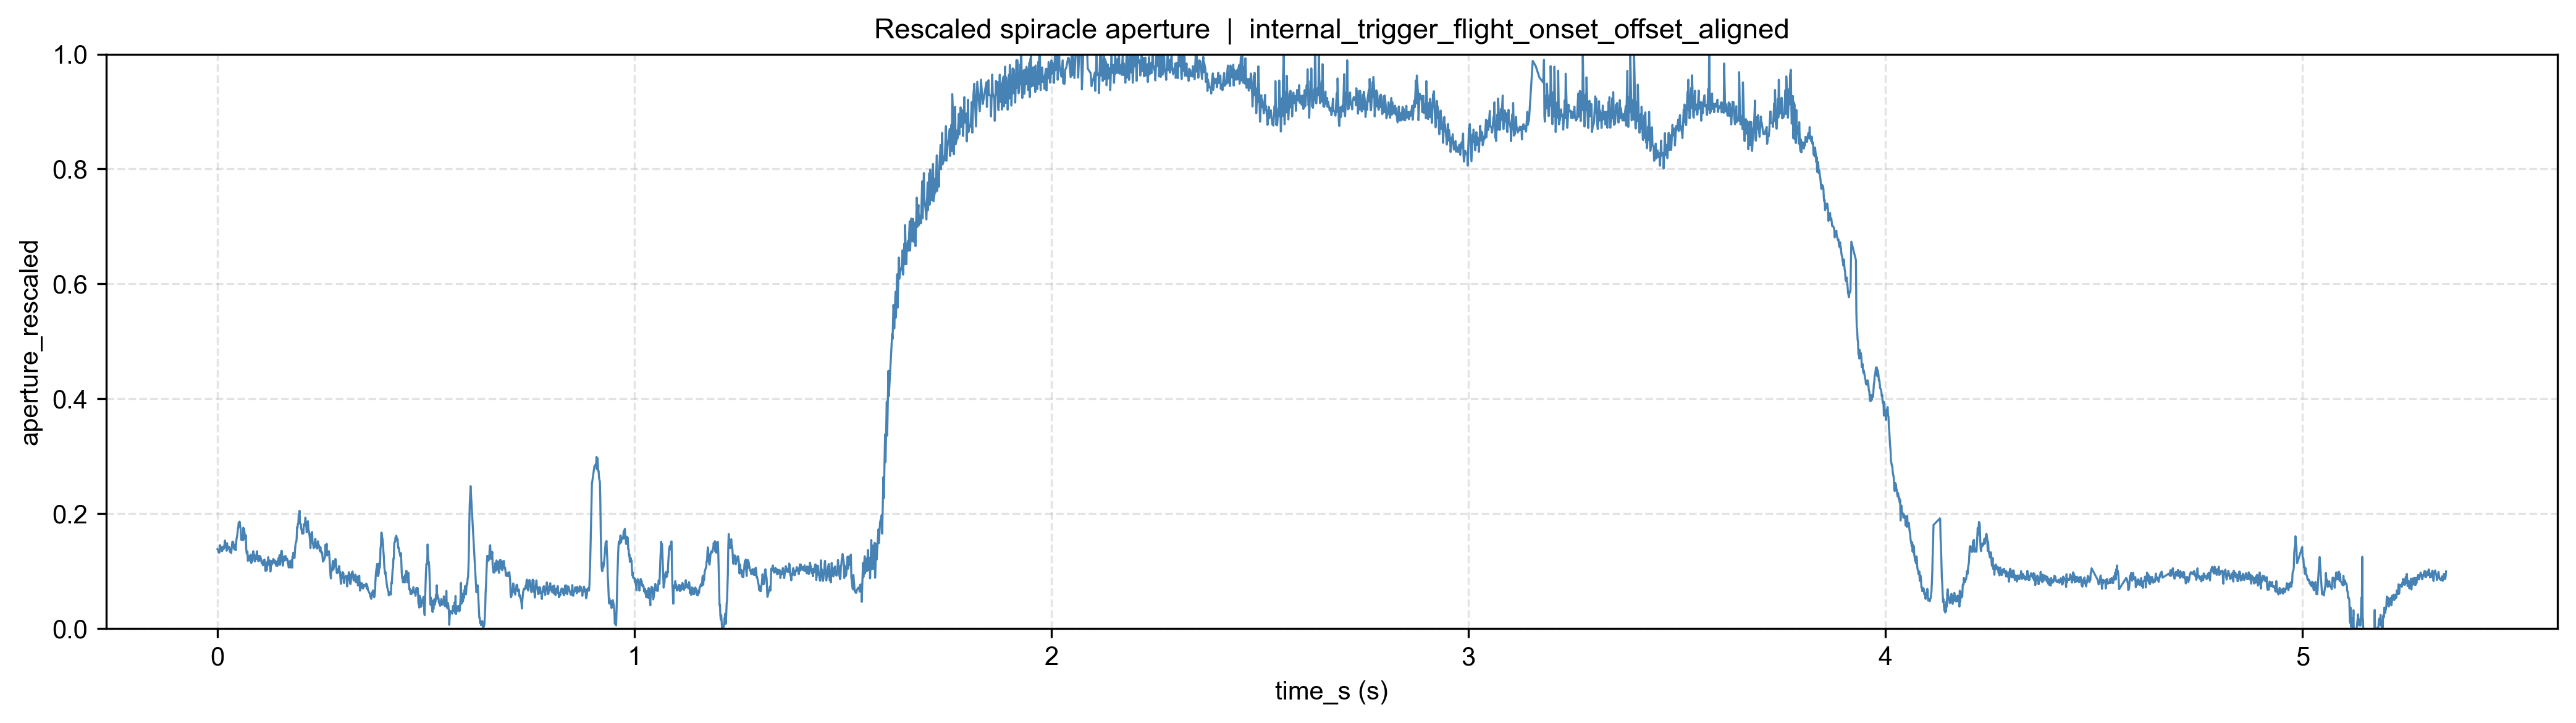

Saved: K:\Yichen\spiracle_movies\internal_trigger_flight_onset_offset_aligned_aperture_rescaled.svg
Saved: K:\Yichen\spiracle_movies\internal_trigger_flight_onset_offset_aligned_aperture_rescaled.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot — rescaled spiracle aperture vs time → SVG + PNG (next to the input)
# 与第一格相同 *_after_correction.csv 同根：写 *_aperture_rescaled.{svg,png}
# Style 参考 Step 1 的 _save_combined_svg：figsize=(14,4)、虚线网格、tight_layout
# ═══════════════════════════════════════════════════════════════════════════════
import os
import pandas as pd
import matplotlib.pyplot as plt

stem    = os.path.splitext(XLSX_FILE)[0]
in_csv  = stem + "_after_correction.csv"
out_svg = stem + "_aperture_rescaled.svg"
out_png = stem + "_aperture_rescaled.png"

plot_df = pd.read_csv(in_csv)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df["time_s"].values, plot_df["aperture_rescaled"].values,
        color="steelblue", linewidth=0.8)
ax.set_xlabel("time_s (s)")
ax.set_ylabel("aperture_rescaled")
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Rescaled spiracle aperture  |  {os.path.basename(stem)}", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()

plt.savefig(out_svg, format="svg")
plt.savefig(out_png, dpi=150)
plt.show()
plt.close(fig)

print(f"Saved: {out_svg}")
print(f"Saved: {out_png}")
